# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Carter Shaffer and Michael Mitchell

**Date:** 9/9/26

Question 1:

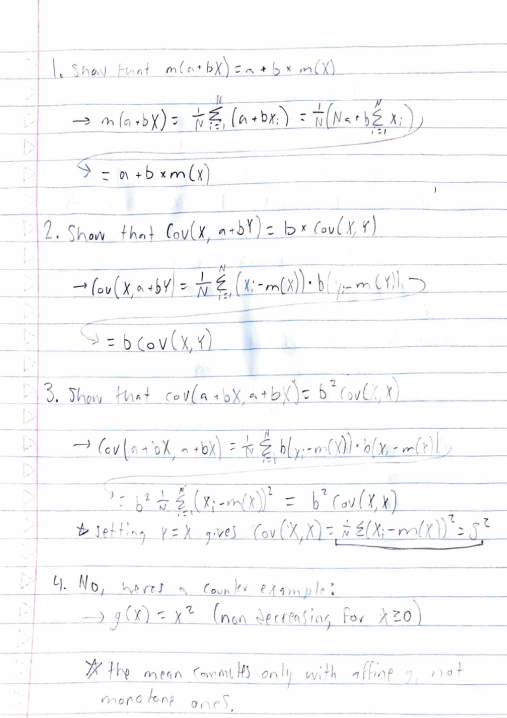

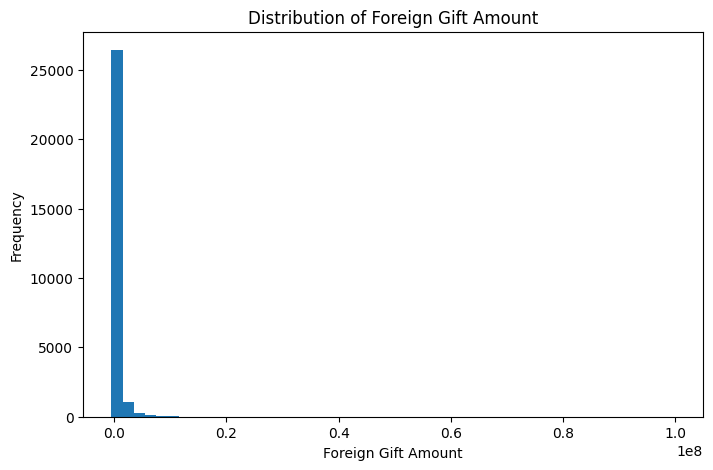

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


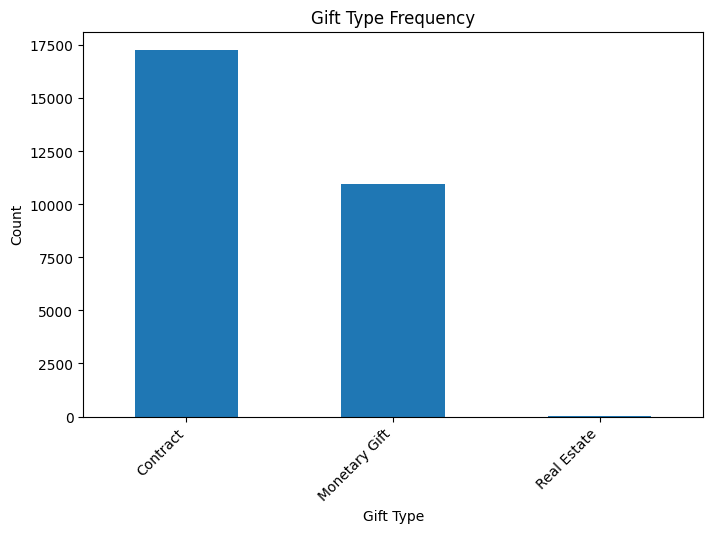

24


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


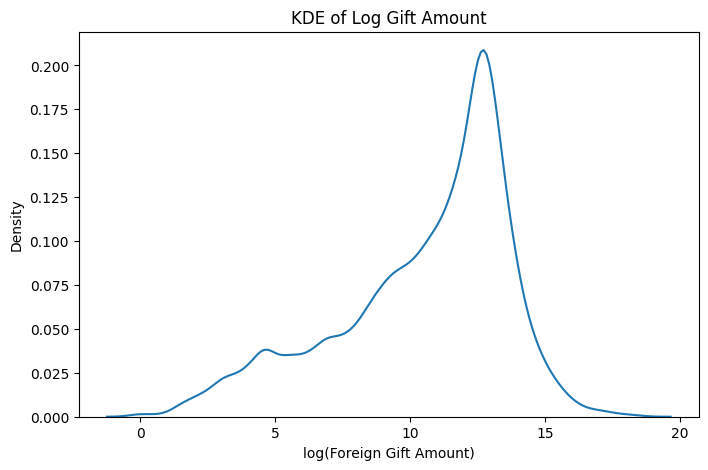

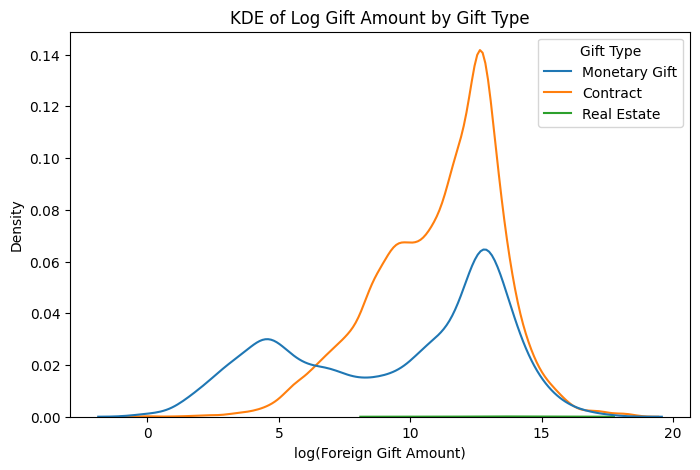

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

In [1]:
# Question 2 solution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load foreign gifts dataset
df = pd.read_csv('ForeignGifts_edu.csv')
df.head()

# Histogram of Foreign Gift Amount
plt.figure(figsize=(8,5))
plt.hist(df['Foreign Gift Amount'], bins=50)
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Foreign Gift Amount')
plt.show()

df['Foreign Gift Amount'].describe()

# Counts and proportions of each Gift Type
gift_type_counts = df['Gift Type'].value_counts()
print(gift_type_counts)

gift_type_props = df['Gift Type'].value_counts(normalize=True)
print(gift_type_props)

# Bar chart of Gift Type frequency
gift_type_counts.plot(kind='bar', figsize=(8,5))
plt.ylabel('Count')
plt.title('Gift Type Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()

# Check how many gift amounts are zero or negative before taking log
print((df['Foreign Gift Amount'] <= 0).sum())

# Log-transform gift amount, then plot overall KDE
df['log_amount'] = np.log(df['Foreign Gift Amount'])
plt.figure(figsize=(8,5))
sns.kdeplot(df['log_amount'])
plt.xlabel('log(Foreign Gift Amount)')
plt.title('KDE of Log Gift Amount')
plt.show()

# KDE of log gift amount, split by Gift Type
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='log_amount', hue='Gift Type')
plt.xlabel('log(Foreign Gift Amount)')
plt.title('KDE of Log Gift Amount by Gift Type')
plt.show()

# Top 15 countries by number of gifts
top15_count = df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False).head(15)
print(top15_count)

# Top 15 countries by total gift amount
top15_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top15_amount)

# Top 15 giftors by total amount given
top_giftors = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top_giftors)

For Foreign Gift Amount, the distribution is extremely right-skewed: most gifts are small, but a few very large gifts (up to ~$2.7 billion) pull the tail far to the right, making the raw histogram hard to read. 24 gifts has a value of zero or negative, a negligible share of the 28,221 total.

For Gift Type, Contracts make up about 61.2% of gifts (17,274), Monetary Gifts about 38.8% (10,936), and Real Estate about 0.04% (11).

After log-transforming Foreign Gift Amount, the distribution is roughly unimodal with a peak around log-amount 12-13. Splitting by Gift Type shows Contracts have a sharper, higher peak in that range, while Monetary Gifts are more spread out with a lower, broader peak, suggesting monetary gift sizes vary more than contract values.

By number of gifts, England (3,655), China (2,461), and Canada (2,344) rank highest. By total dollar amount, Qatar leads by a wide margin (2.7B), followed by England (1.46B) and China (1.24B). Qatar doesn't appear in the top 10 by count, meaning its gifts are comparatively few but very large. It's also worth noting that "Korea" and "South Korea" appear as seperate entries, likely a data entry inconsistency rather than two distinct countries.

The largest giftors are all Qatar-linked. Qatar Foundation ($1.17B), Qatar Foundation/Qatar National Res (796M), and Qatar Foundation for Education (374M), which together likely represent one organization recorded under different names. Other top giftors include Saudi government-linked entities and two "Anonymous" donors totaling over 400M combined.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** e5d559034d505e05e40e1d0e3f791c7e9e274a4c
- **AI tool and model used:** Claude Opus 5.0

### *Prompts used

1. Im working on this assignment for my Intro to machine learning class, I want you to help me fix any errors or simplify my logic where necessary. Only address the problems within the prompt, nothing extra. Assignment:
2. organize this into steps for me to correc tthe issues - focus on the main ones


### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. The log transform is the real bug
2. Conditional KDE is misleading by default
3. Raw histogram will be one spike

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept  | better logic for filtering before using the log |
| 2 | Accept  | correctly re-points the KDE's  |
| 3 | Accept  | Modifies the histogram to have a better display that is more defined  |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

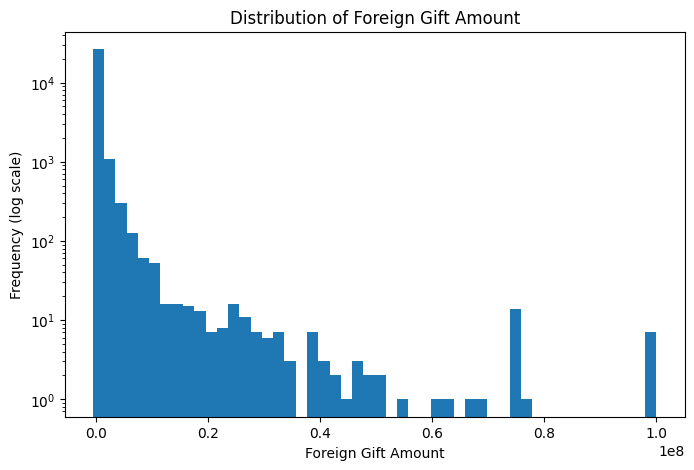

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


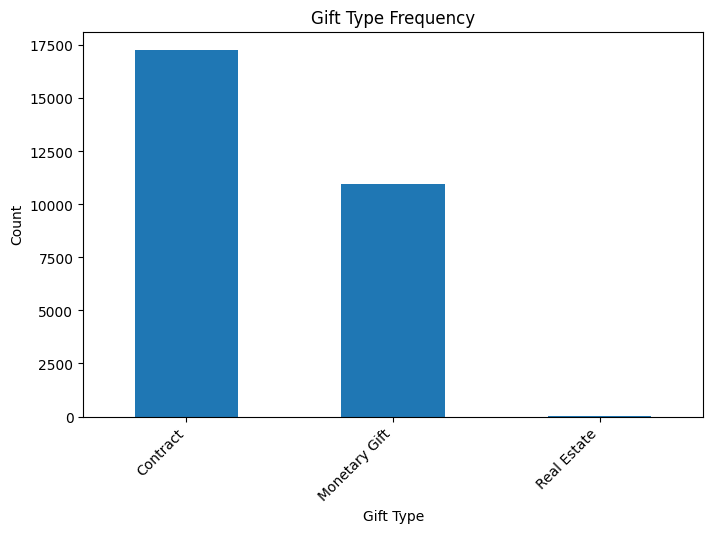

Non-positive amounts dropped: 24


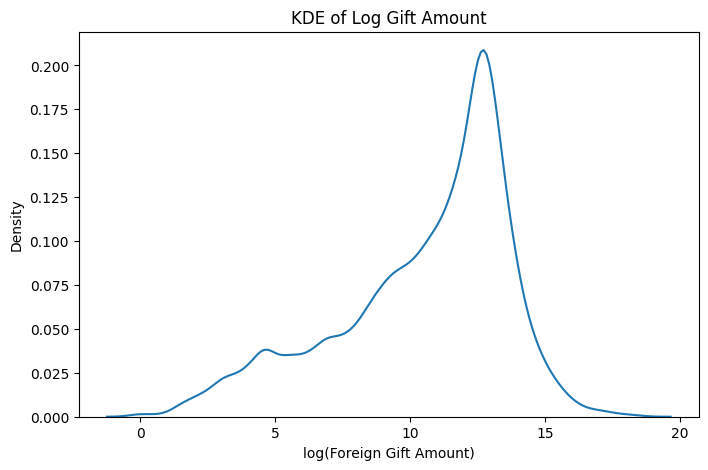

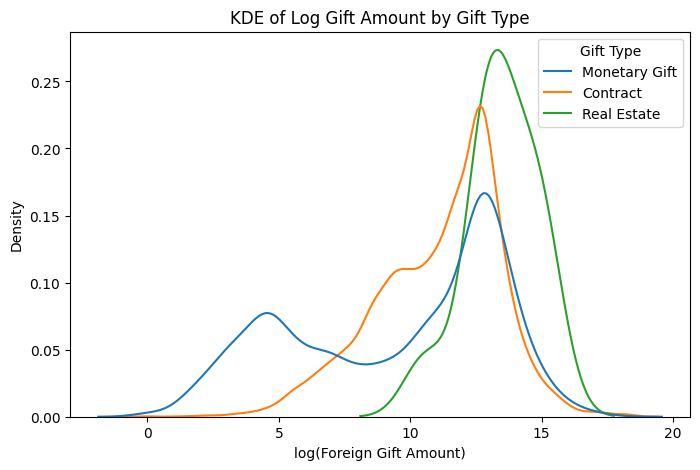

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

In [4]:
# Question 2:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load foreign gifts dataset
df = pd.read_csv('ForeignGifts_edu.csv')
df.head()

# Histogram of Foreign Gift Amount
plt.figure(figsize=(8,5))
plt.hist(df['Foreign Gift Amount'], bins=50)
plt.yscale('log')
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Foreign Gift Amount')
plt.show()

df['Foreign Gift Amount'].describe()

# Counts and proportions of each Gift Type
gift_type_counts = df['Gift Type'].value_counts()
print(gift_type_counts)

gift_type_props = df['Gift Type'].value_counts(normalize=True)
print(gift_type_props)

# Bar chart of Gift Type frequency
gift_type_counts.plot(kind='bar', figsize=(8,5))
plt.ylabel('Count')
plt.title('Gift Type Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()

# Check how many gift amounts are zero or negative, then filter them out
n_bad = (df['Foreign Gift Amount'] <= 0).sum()
print(f'Non-positive amounts dropped: {n_bad}')

df_pos = df[df['Foreign Gift Amount'] > 0].copy()
df_pos['log_amount'] = np.log(df_pos['Foreign Gift Amount'])

# Overall KDE of log gift amount
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_pos, x='log_amount')
plt.xlabel('log(Foreign Gift Amount)')
plt.title('KDE of Log Gift Amount')
plt.show()

# KDE of log gift amount, split by Gift Type
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_pos, x='log_amount', hue='Gift Type', common_norm=False)
plt.xlabel('log(Foreign Gift Amount)')
plt.title('KDE of Log Gift Amount by Gift Type')
plt.show()

# Top 15 countries by number of gifts
top15_count = df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False).head(15)
print(top15_count)

# Top 15 countries by total gift amount
top15_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top15_amount)

# Top 15 giftors by total amount given
top_giftors = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top_giftors)


### *Reflection on AI assistance
In your own words without generative AI.

The improvements that AI made were 3 main fixes. Transforming the log was the main bug, the code counted to zero and negative gift amounts, printed the count, and then logged this whole column anyway. Now it filters to positive values first. The conditional KDE was using seaborns default, which would scale each curve by group size and flatten gift types. Lastly, the histogram was one spike, so it added a log y axis to better display. The main limitation was that AI couldnt accurately read the png for question 1, so it was oly able to revise q2. I think all and all the AI was beneficial in this assignment and caught errors that I had made in the code.